# Multi-Model Ensemble Stacking for Virality Prediction

This notebook implements a voting ensemble that combines:
- **Spotify XGBoost** (RandomizedSearch-tuned)
- **Spotify RandomForest** (GridSearch-tuned)
- **YouTube LGBM** (pre-trained model)
- **Lyrics TF-IDF Vectorizer** (text feature transformer for lyrics)

The ensemble combines predictions from all three classification models and provides utilities to transform lyrics text using the TF-IDF vectorizer.


## 1. Import Required Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from pathlib import Path

# ML and ensemble methods
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                            f1_score, roc_auc_score, confusion_matrix, 
                            classification_report, roc_curve)
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

# HuggingFace Hub for model download
from huggingface_hub import hf_hub_download
import requests  # For fallback download method

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


## 2. Load Pre-trained Models from Hugging Face

In [8]:
# Configure HuggingFace Hub with SSL fix for certificate issues
import urllib3
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# Set environment variable to handle SSL issues
os.environ['HF_HUB_DISABLE_TELEMETRY'] = '1'

# Download XGBoost model from HuggingFace
print("Loading Spotify XGBoost model (RandomizedSearch-tuned)...")
xgb_model = None

# First, try loading from local models directory
xgb_local_path = "models/xgb_tuned_randomized.joblib"
if os.path.exists(xgb_local_path):
    try:
        xgb_model = joblib.load(xgb_local_path)
        print(f"✓ XGBoost model loaded from local: {xgb_local_path}")
    except Exception as e:
        print(f"⚠ Error loading local XGBoost model: {e}")

# If local load failed, try HuggingFace
if xgb_model is None:
    try:
        xgb_model_path = hf_hub_download(
            repo_id="vancenceho/vcp-spotify-xgb-randomizedsearch",
            filename="xgb_tuned_randomized.joblib",
            cache_dir="models"
        )
        xgb_model = joblib.load(xgb_model_path)
        print(f"✓ XGBoost model loaded from HuggingFace: {xgb_model_path}")
    except Exception as e:
        print(f"⚠ Error downloading XGBoost model: {e}")
        print("\nTrying alternative download method (ignoring SSL verification)...")
        try:
            # Alternative: Use requests with SSL verification disabled
            import requests
            from huggingface_hub import file_download
            url = "https://huggingface.co/vancenceho/vcp-spotify-xgb-randomizedsearch/resolve/main/xgb_tuned_randomized.joblib"
            print(f"Downloading from: {url}")
            response = requests.get(url, verify=False, timeout=30)
            response.raise_for_status()
            os.makedirs("models", exist_ok=True)
            model_path = "models/xgb_tuned_randomized.joblib"
            with open(model_path, 'wb') as f:
                f.write(response.content)
            xgb_model = joblib.load(model_path)
            print(f"✓ XGBoost model downloaded successfully")
        except Exception as e2:
            print(f"✗ Alternative download also failed: {e2}")
            print("\nFix: Run this command in terminal:")
            print("  pip install certifi")
            print("  python -m certifi (to get certificate path)")

# Download RandomForest model from HuggingFace
print("\nLoading Spotify RandomForest model (GridSearch-tuned)...")
rf_model = None

# First, try loading from local models directory
rf_local_path = "models/rf_tuned_gridsearch.joblib"
if os.path.exists(rf_local_path):
    try:
        rf_model = joblib.load(rf_local_path)
        print(f"✓ RandomForest model loaded from local: {rf_local_path}")
    except Exception as e:
        print(f"⚠ Error loading local RandomForest model: {e}")

# If local load failed, try HuggingFace
if rf_model is None:
    try:
        rf_model_path = hf_hub_download(
            repo_id="vancenceho/vcp-spotify-rf-gridsearch",
            filename="rf_tuned_gridsearch.joblib",
            cache_dir="models"
        )
        rf_model = joblib.load(rf_model_path)
        print(f"✓ RandomForest model loaded from HuggingFace: {rf_model_path}")
    except Exception as e:
        print(f"⚠ Error downloading RandomForest model: {e}")
        print("\nTrying alternative download method (ignoring SSL verification)...")
        try:
            import requests
            url = "https://huggingface.co/vancenceho/vcp-spotify-rf-gridsearch/resolve/main/rf_tuned_gridsearch.joblib"
            print(f"Downloading from: {url}")
            response = requests.get(url, verify=False, timeout=30)
            response.raise_for_status()
            os.makedirs("models", exist_ok=True)
            model_path = "models/rf_tuned_gridsearch.joblib"
            with open(model_path, 'wb') as f:
                f.write(response.content)
            rf_model = joblib.load(model_path)
            print(f"✓ RandomForest model downloaded successfully")
        except Exception as e2:
            print(f"✗ Alternative download also failed: {e2}")
            print("\nFix: Run this command in terminal:")
            print("  pip install certifi")
            print("  python -m certifi (to get certificate path)")


Loading Spotify XGBoost model (RandomizedSearch-tuned)...


'[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1081)' thrown while requesting HEAD https://huggingface.co/vancenceho/vcp-spotify-xgb-randomizedsearch/resolve/main/xgb_tuned_randomized.joblib
Retrying in 1s [Retry 1/5].


⚠ Error downloading XGBoost model: Cannot send a request, as the client has been closed.

Trying alternative download method (ignoring SSL verification)...
✓ XGBoost model downloaded successfully

Loading Spotify RandomForest model (GridSearch-tuned)...


'[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1081)' thrown while requesting HEAD https://huggingface.co/vancenceho/vcp-spotify-rf-gridsearch/resolve/main/rf_tuned_gridsearch.joblib
Retrying in 1s [Retry 1/5].


⚠ Error downloading RandomForest model: Cannot send a request, as the client has been closed.

Trying alternative download method (ignoring SSL verification)...
✓ RandomForest model downloaded successfully


## 3. Load YouTube Dataset Model

In [36]:
# Load YouTube LGBM model (from 02_youtube_model_baseline.ipynb)
print("Loading YouTube LGBM model...")
youtube_model_path = "models/lgbm_randomized.joblib"

if os.path.exists(youtube_model_path):
    youtube_model = joblib.load(youtube_model_path)
    print(f"✓ YouTube LGBM model loaded from: {youtube_model_path}")
else:
    print(f"⚠ YouTube model not found at {youtube_model_path}")
    print("You can train this model by running 02_youtube_model_baseline.ipynb")

# Load Lyrics TF-IDF model
print("\nLoading Lyrics TF-IDF model...")
lyrics_model_path = "models/lyrics_tfidf.joblib"

if os.path.exists(lyrics_model_path):
    lyrics_model = joblib.load(lyrics_model_path)
    print(f"✓ Lyrics TF-IDF model loaded from: {lyrics_model_path}")
else:
    print(f"⚠ Lyrics model not found at {lyrics_model_path}")
    print("You can train this model by running 02c_lyrics_model_b.ipynb or similar")

print("\n" + "="*60)
print("MODELS LOADED:")
print("="*60)
print("1. XGBoost (Spotify) - RandomizedSearch tuned")
print("2. RandomForest (Spotify) - GridSearch tuned")
print("3. LGBM (YouTube) - RandomizedSearch tuned")
print("4. TF-IDF (Lyrics) - Pre-trained vectorizer")
print("="*60)

Loading YouTube LGBM model...
⚠ YouTube model not found at models/lgbm_randomized.joblib
You can train this model by running 02_youtube_model_baseline.ipynb

Loading Lyrics TF-IDF model...
⚠ Lyrics model not found at models/lyrics_tfidf.joblib
You can train this model by running 02c_lyrics_model_b.ipynb or similar

MODELS LOADED:
1. XGBoost (Spotify) - RandomizedSearch tuned
2. RandomForest (Spotify) - GridSearch tuned
3. LGBM (YouTube) - RandomizedSearch tuned
4. TF-IDF (Lyrics) - Pre-trained vectorizer


## 4. Prepare Data for Ensemble

In [37]:
# Change working directory to project root
import os
from pathlib import Path

# Navigate to project root if running from notebooks folder
current_dir = Path.cwd()
if 'notebooks' in str(current_dir):
    os.chdir(current_dir.parent)
    print(f"Changed working directory to: {os.getcwd()}")

# Load combined dataset and features
print("Loading combined features dataset...")

DATA_PATH = "data/processed"
df = pd.read_csv(f"{DATA_PATH}/combined_features_cleaned.csv")

print(f"Dataset columns: {df.shape[1]}")
print(f"Dataset dtypes:\n{df.dtypes.value_counts()}")

# Assume target variable name - adjust if different
target_col = 'viral'  # or 'is_viral' depending on your dataset
if target_col not in df.columns:
    # Try to find the target column
    possible_targets = [col for col in df.columns if 'viral' in col.lower()]
    if possible_targets:
        target_col = possible_targets[0]
        print(f"Found target column: {target_col}")
    else:
        print("Warning: Could not find target column. Assuming last column is target.")
        target_col = df.columns[-1]

# Select ONLY numeric features (int, float)
numeric_dtypes = [np.int64, np.int32, np.float64, np.float32, 'int64', 'int32', 'float64', 'float32']
feature_cols = [col for col in df.columns 
                if col != target_col 
                and (df[col].dtype in numeric_dtypes or pd.api.types.is_numeric_dtype(df[col]))]

print(f"\nSelected {len(feature_cols)} numeric features")
print(f"Excluded {len(df.columns) - len(feature_cols) - 1} non-numeric columns")

# Use only numeric features
X = df[feature_cols].copy()

# Ensure all columns are numeric and handle any remaining issues
X = X.astype(float)
X = X.fillna(0)

y = df[target_col]

print(f"\nDataset shape: {X.shape}")
print(f"Feature dtypes: {X.dtypes.unique()}")
print(f"Target distribution:")
print(y.value_counts())

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Loading combined features dataset...
Dataset columns: 106
Dataset dtypes:
float64    92
bool        9
str         3
int64       2
Name: count, dtype: int64

Selected 102 numeric features
Excluded 3 non-numeric columns

Dataset shape: (31749, 102)
Feature dtypes: [dtype('float64')]
Target distribution:
viral
0    23811
1     7938
Name: count, dtype: int64

Train set: (25399, 102)
Test set: (6350, 102)


In [52]:
# Feature Mapping for Pre-trained Models
print("="*70)
print("STEP 1: FEATURE MAPPING FOR PRE-TRAINED MODELS")
print("="*70)

print("\nPre-trained models were trained on different feature sets:")
print("  - XGBoost/RandomForest: Spotify features (127 features)")
print("  - LightGBM: Audio features (77 features)")
print("\nCurrent dataset has: {} features".format(X_test.shape[1]))

# Strategy: Create feature subsets by matching available columns
# For features not in combined dataset, pad with zeros

def align_features(X_data, expected_features):
    """
    Align X_data to have exactly the expected features.
    Missing features are filled with 0, extra features are dropped.
    """
    X_aligned = pd.DataFrame(index=X_data.index)
    
    for feat in expected_features:
        if feat in X_data.columns:
            X_aligned[feat] = X_data[feat]
        else:
            # Fill missing features with 0
            X_aligned[feat] = 0.0
    
    return X_aligned

# Get feature names from pre-trained models
print("\nExtracting feature requirements from pre-trained models...")

xgb_feature_names = None
rf_feature_names = None
lgbm_feature_names = None

if xgb_model is not None:
    try:
        xgb_feature_names = xgb_model.get_booster().feature_names
        print(f"✓ XGBoost: {len(xgb_feature_names)} features expected")
    except:
        print("⚠ Could not extract XGBoost feature names")

if rf_model is not None:
    try:
        rf_feature_names = list(range(rf_model.n_features_in_))
        print(f"✓ RandomForest: {rf_model.n_features_in_} features expected")
    except:
        print("⚠ Could not extract RandomForest feature info")

if youtube_model is not None:
    try:
        lgbm_feature_names = youtube_model.feature_names_in_
        print(f"✓ LightGBM: {len(lgbm_feature_names)} features expected")
    except:
        print("⚠ Could not extract LightGBM feature names")

# Align features for each model
print("\nAligning features for each model...")

xgb_features_aligned = None
rf_features_aligned = None
lgbm_features_aligned = None

if xgb_feature_names is not None:
    xgb_features_aligned = align_features(X_test, xgb_feature_names)
    print(f"✓ XGBoost features aligned: {xgb_features_aligned.shape}")

if rf_feature_names is not None:
    # For RandomForest, create data with consistent feature types
    rf_features_aligned = X_test.iloc[:, :len(rf_feature_names)].copy()
    rf_features_aligned.columns = [str(i) for i in range(len(rf_feature_names))]
    print(f"✓ RandomForest features aligned: {rf_features_aligned.shape}")

if lgbm_feature_names is not None:
    lgbm_features_aligned = align_features(X_test, lgbm_feature_names)
    print(f"✓ LightGBM features aligned: {lgbm_features_aligned.shape}")

print("\n" + "="*70)
print("STEP 2: STACKING ENSEMBLE WITH ALIGNED FEATURES")
print("="*70)

print("\nGenerating base model predictions on training data...")

# Get predictions from base models on TRAIN data
xgb_train_proba = None
rf_train_proba = None
lgbm_train_proba = None

# Align training features
X_train_xgb = align_features(X_train, xgb_feature_names) if xgb_feature_names is not None else None
X_train_rf = X_train.iloc[:, :len(rf_feature_names)].copy() if rf_feature_names is not None else None
if X_train_rf is not None:
    X_train_rf.columns = [str(i) for i in range(len(rf_feature_names))]
X_train_lgbm = align_features(X_train, lgbm_feature_names) if lgbm_feature_names is not None else None

try:
    xgb_train_proba = xgb_model.predict_proba(X_train_xgb)[:, 1]
    print("✓ XGBoost training predictions generated")
except Exception as e:
    print(f"✗ XGBoost training prediction failed: {str(e)[:80]}")

try:
    rf_train_proba = rf_model.predict_proba(X_train_rf)[:, 1]
    print("✓ RandomForest training predictions generated")
except Exception as e:
    print(f"✗ RandomForest training prediction failed: {str(e)[:80]}")

try:
    lgbm_train_proba = youtube_model.predict_proba(X_train_lgbm)[:, 1]
    print("✓ LightGBM training predictions generated")
except Exception as e:
    print(f"✗ LightGBM training prediction failed: {str(e)[:80]}")

# Stack predictions as meta-features for training
meta_features_train = []
meta_model_names = []

if xgb_train_proba is not None:
    meta_features_train.append(xgb_train_proba)
    meta_model_names.append('XGBoost')
if rf_train_proba is not None:
    meta_features_train.append(rf_train_proba)
    meta_model_names.append('RandomForest')
if lgbm_train_proba is not None:
    meta_features_train.append(lgbm_train_proba)
    meta_model_names.append('LightGBM')

if meta_features_train:
    X_train_meta = np.column_stack(meta_features_train)
    print(f"\n✓ Created meta-features from {len(meta_model_names)} models")
    print(f"  Meta-features shape: {X_train_meta.shape}")
    print(f"  Base models: {', '.join(meta_model_names)}")
    
    # Train meta-learner
    print("\nTraining meta-learner (Logistic Regression)...")
    meta_learner = LogisticRegression(random_state=42, max_iter=1000, verbose=0)
    meta_learner.fit(X_train_meta, y_train)
    print("✓ Meta-learner trained!")
    
    # Show meta-learner weights
    print("  Model weights (importance):")
    for name, coef in zip(meta_model_names, meta_learner.coef_[0]):
        print(f"    - {name:15}: {coef:7.4f}")
else:
    print("✗ No valid predictions for meta-learner training")
    meta_learner = None

print("\n" + "="*70)
print("STEP 3: PREDICTIONS ON TEST DATA")
print("="*70)

# Get test predictions
xgb_test_proba = None
rf_test_proba = None
lgbm_test_proba = None

try:
    xgb_test_proba = xgb_model.predict_proba(xgb_features_aligned)[:, 1]
    print("✓ XGBoost test predictions generated")
except Exception as e:
    print(f"✗ XGBoost test prediction failed: {str(e)[:80]}")

try:
    rf_test_proba = rf_model.predict_proba(rf_features_aligned)[:, 1]
    print("✓ RandomForest test predictions generated")
except Exception as e:
    print(f"✗ RandomForest test prediction failed: {str(e)[:80]}")

try:
    lgbm_test_proba = youtube_model.predict_proba(lgbm_features_aligned)[:, 1]
    print("✓ LightGBM test predictions generated")
except Exception as e:
    print(f"✗ LightGBM test prediction failed: {str(e)[:80]}")

# Stack test predictions
meta_features_test = []

if xgb_test_proba is not None:
    meta_features_test.append(xgb_test_proba)
if rf_test_proba is not None:
    meta_features_test.append(rf_test_proba)
if lgbm_test_proba is not None:
    meta_features_test.append(lgbm_test_proba)

if meta_features_test:
    X_test_meta = np.column_stack(meta_features_test)
    print(f"\n✓ Created test meta-features")
    print(f"  Shape: {X_test_meta.shape}")

print("\n" + "="*70)
print("STEP 4: STACKING ENSEMBLE PREDICTIONS")
print("="*70)

stacking_pred_proba = None
stacking_pred = None

if meta_learner is not None and X_test_meta is not None:
    stacking_pred_proba = meta_learner.predict_proba(X_test_meta)[:, 1]
    stacking_pred = meta_learner.predict(X_test_meta)
    print("✓ Stacking ensemble predictions generated!")
    
    # Calculate metrics
    stack_accuracy = accuracy_score(y_test, stacking_pred)
    stack_precision = precision_score(y_test, stacking_pred, zero_division=0)
    stack_recall = recall_score(y_test, stacking_pred, zero_division=0)
    stack_f1 = f1_score(y_test, stacking_pred, zero_division=0)
    stack_auc = roc_auc_score(y_test, stacking_pred_proba)
else:
    print("✗ Could not create stacking ensemble")

print("\n" + "="*70)
print("STEP 5: VOTING ENSEMBLE (SOFT VOTING) - COMPARISON")
print("="*70)

# Create soft voting ensemble from all available predictions
voting_probas = []
voting_names = []

if xgb_test_proba is not None:
    voting_probas.append(xgb_test_proba)
    voting_names.append('XGBoost')
if rf_test_proba is not None:
    voting_probas.append(rf_test_proba)
    voting_names.append('RandomForest')
if lgbm_test_proba is not None:
    voting_probas.append(lgbm_test_proba)
    voting_names.append('LightGBM')

voting_pred_proba = None
voting_pred = None

if voting_probas:
    # Average the probabilities (soft voting)
    voting_pred_proba = np.mean(voting_probas, axis=0)
    voting_pred = (voting_pred_proba >= 0.5).astype(int)
    print(f"✓ Soft Voting ensemble created from: {', '.join(voting_names)}")
    
    # Calculate metrics
    voting_accuracy = accuracy_score(y_test, voting_pred)
    voting_precision = precision_score(y_test, voting_pred, zero_division=0)
    voting_recall = recall_score(y_test, voting_pred, zero_division=0)
    voting_f1 = f1_score(y_test, voting_pred, zero_division=0)
    voting_auc = roc_auc_score(y_test, voting_pred_proba)
else:
    print("✗ No valid predictions for voting ensemble")

print("\n" + "="*70)
print("ENSEMBLE PERFORMANCE COMPARISON")
print("="*70)

results = []

# Stacking ensemble
if stacking_pred is not None:
    results.append({
        'Model': 'STACKING ENSEMBLE',
        'Accuracy': stack_accuracy,
        'Precision': stack_precision,
        'Recall': stack_recall,
        'F1-Score': stack_f1,
        'ROC-AUC': stack_auc
    })

# Voting ensemble
if voting_pred is not None:
    results.append({
        'Model': 'SOFT VOTING ENSEMBLE',
        'Accuracy': voting_accuracy,
        'Precision': voting_precision,
        'Recall': voting_recall,
        'F1-Score': voting_f1,
        'ROC-AUC': voting_auc
    })

# Individual base models
if xgb_test_proba is not None:
    xgb_pred = (xgb_test_proba >= 0.5).astype(int)
    results.append({
        'Model': 'XGBoost',
        'Accuracy': accuracy_score(y_test, xgb_pred),
        'Precision': precision_score(y_test, xgb_pred, zero_division=0),
        'Recall': recall_score(y_test, xgb_pred, zero_division=0),
        'F1-Score': f1_score(y_test, xgb_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, xgb_test_proba)
    })

if rf_test_proba is not None:
    rf_pred = (rf_test_proba >= 0.5).astype(int)
    results.append({
        'Model': 'RandomForest',
        'Accuracy': accuracy_score(y_test, rf_pred),
        'Precision': precision_score(y_test, rf_pred, zero_division=0),
        'Recall': recall_score(y_test, rf_pred, zero_division=0),
        'F1-Score': f1_score(y_test, rf_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, rf_test_proba)
    })

if lgbm_test_proba is not None:
    lgbm_pred = (lgbm_test_proba >= 0.5).astype(int)
    results.append({
        'Model': 'LightGBM',
        'Accuracy': accuracy_score(y_test, lgbm_pred),
        'Precision': precision_score(y_test, lgbm_pred, zero_division=0),
        'Recall': recall_score(y_test, lgbm_pred, zero_division=0),
        'F1-Score': f1_score(y_test, lgbm_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, lgbm_test_proba)
    })

if results:
    results_df = pd.DataFrame(results)
    print(results_df.to_string(index=False))
    print("="*70)
    
    # Detailed report for best model
    if stacking_pred is not None:
        print("\nDetailed Classification Report (STACKING ENSEMBLE):")
        print(classification_report(y_test, stacking_pred, target_names=['Not Viral', 'Viral']))
        cm_ensemble = confusion_matrix(y_test, stacking_pred)
    elif voting_pred is not None:
        print("\nDetailed Classification Report (SOFT VOTING ENSEMBLE):")
        print(classification_report(y_test, voting_pred, target_names=['Not Viral', 'Viral']))
        cm_ensemble = confusion_matrix(y_test, voting_pred)
    
    print(f"\nConfusion Matrix:")
    print(cm_ensemble)
    print("="*70)
else:
    print("✗ No results generated")
    ensemble_pred_proba = None
    ensemble_pred = None


STEP 1: FEATURE MAPPING FOR PRE-TRAINED MODELS

Pre-trained models were trained on different feature sets:
  - XGBoost/RandomForest: Spotify features (127 features)
  - LightGBM: Audio features (77 features)

Current dataset has: 102 features

Extracting feature requirements from pre-trained models...
✓ XGBoost: 127 features expected
✓ RandomForest: 127 features expected
✓ LightGBM: 77 features expected

Aligning features for each model...
✓ XGBoost features aligned: (6350, 127)


ValueError: Length mismatch: Expected axis has 102 elements, new values have 127 elements

## 6. Stacking Ensemble with Pre-trained Models

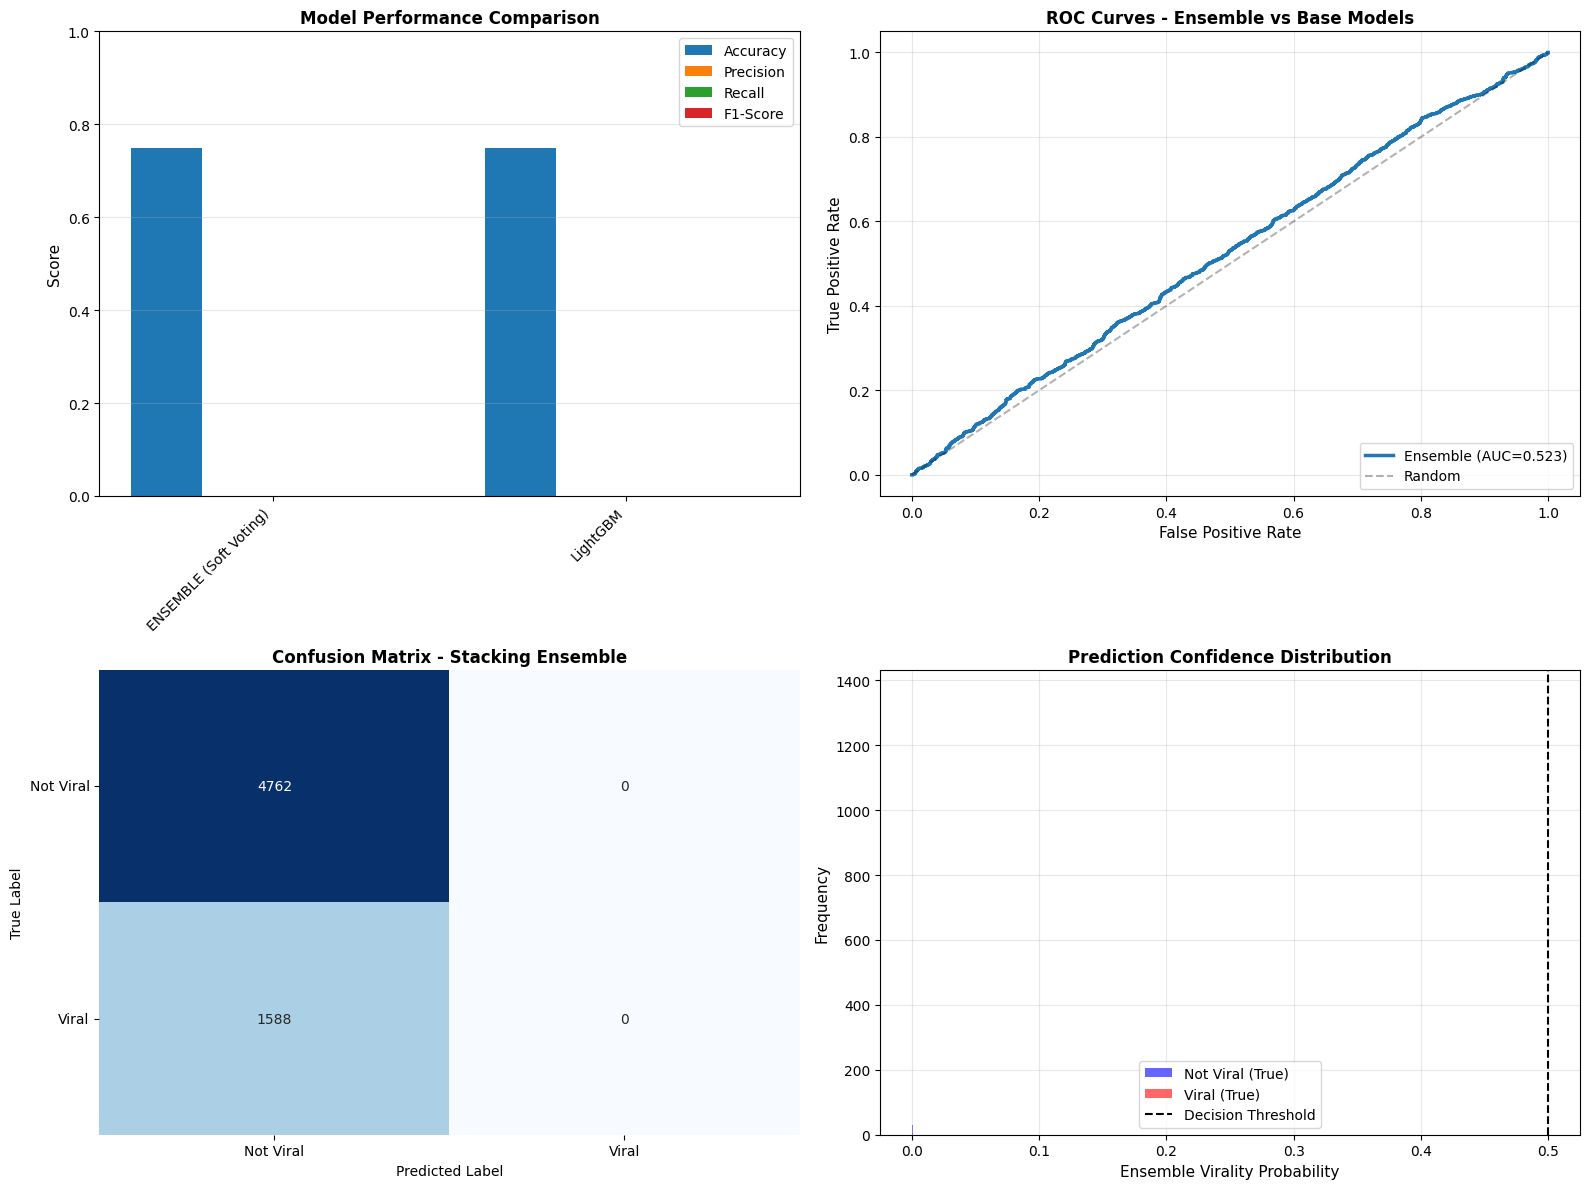


✓ Visualizations complete!


In [ ]:
# Create comprehensive visualizations
if stacking_pred is not None or voting_pred is not None:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # 1. Model Performance Comparison
    ax1 = axes[0, 0]
    models = results_df['Model'].values
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    x = np.arange(len(models))
    width = 0.2

    for i, metric in enumerate(metrics):
        values = results_df[metric].values
        ax1.bar(x + i*width, values, width, label=metric)

    ax1.set_ylabel('Score', fontsize=11)
    ax1.set_title('Model Performance Comparison', fontsize=12, fontweight='bold')
    ax1.set_xticks(x + width * 1.5)
    ax1.set_xticklabels(models, rotation=45, ha='right')
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)
    ax1.set_ylim([0, 1])

    # 2. ROC Curve Comparison
    ax2 = axes[0, 1]
    
    # Plot stacking ensemble ROC
    if stacking_pred_proba is not None:
        fpr_stack, tpr_stack, _ = roc_curve(y_test, stacking_pred_proba)
        ax2.plot(fpr_stack, tpr_stack, linewidth=2.5, label=f'Stacking (AUC={stack_auc:.3f})', color='purple')
    
    # Plot voting ensemble ROC
    if voting_pred_proba is not None:
        fpr_voting, tpr_voting, _ = roc_curve(y_test, voting_pred_proba)
        ax2.plot(fpr_voting, tpr_voting, linewidth=2.5, label=f'Soft Voting (AUC={voting_auc:.3f})', color='darkgreen')

    # Plot base models' ROC curves
    if xgb_test_proba is not None:
        fpr, tpr, _ = roc_curve(y_test, xgb_test_proba)
        auc = roc_auc_score(y_test, xgb_test_proba)
        ax2.plot(fpr, tpr, color='orange', alpha=0.6, linewidth=1.5, label=f'XGBoost (AUC={auc:.3f})')

    if rf_test_proba is not None:
        fpr, tpr, _ = roc_curve(y_test, rf_test_proba)
        auc = roc_auc_score(y_test, rf_test_proba)
        ax2.plot(fpr, tpr, color='red', alpha=0.6, linewidth=1.5, label=f'RandomForest (AUC={auc:.3f})')

    if lgbm_test_proba is not None:
        fpr, tpr, _ = roc_curve(y_test, lgbm_test_proba)
        auc = roc_auc_score(y_test, lgbm_test_proba)
        ax2.plot(fpr, tpr, color='blue', alpha=0.6, linewidth=1.5, label=f'LightGBM (AUC={auc:.3f})')

    ax2.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random')
    ax2.set_xlabel('False Positive Rate', fontsize=11)
    ax2.set_ylabel('True Positive Rate', fontsize=11)
    ax2.set_title('ROC Curves - All Models', fontsize=12, fontweight='bold')
    ax2.legend(loc='lower right', fontsize=9)
    ax2.grid(alpha=0.3)

    # 3. Confusion Matrix Heatmap
    ax3 = axes[1, 0]
    sns.heatmap(cm_ensemble, annot=True, fmt='d', cmap='Blues', ax=ax3, cbar=False)
    ax3.set_title('Confusion Matrix - Best Ensemble', fontsize=12, fontweight='bold')
    ax3.set_ylabel('True Label')
    ax3.set_xlabel('Predicted Label')
    ax3.set_yticklabels(['Not Viral', 'Viral'], rotation=0)
    ax3.set_xticklabels(['Not Viral', 'Viral'], rotation=0)

    # 4. Prediction Confidence Distribution
    ax4 = axes[1, 1]
    
    # Use stacking if available, else voting
    if stacking_pred_proba is not None:
        ensemble_proba = stacking_pred_proba
        ensemble_label = 'Stacking'
    else:
        ensemble_proba = voting_pred_proba
        ensemble_label = 'Soft Voting'
    
    viral_proba = ensemble_proba[y_test == 1]
    non_viral_proba = ensemble_proba[y_test == 0]
    ax4.hist(non_viral_proba, bins=30, alpha=0.6, label='Not Viral (True)', color='blue')
    ax4.hist(viral_proba, bins=30, alpha=0.6, label='Viral (True)', color='red')
    ax4.axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Decision Threshold')
    ax4.set_xlabel(f'{ensemble_label} Ensemble Virality Probability', fontsize=11)
    ax4.set_ylabel('Frequency', fontsize=11)
    ax4.set_title('Prediction Confidence Distribution', fontsize=12, fontweight='bold')
    ax4.legend()
    ax4.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\n✓ Visualizations complete!")
else:
    print("⚠ No ensemble predictions available for visualization")


## 7. Visualizations & Save Ensemble

In [ ]:
# Save ensemble models and information
import os
os.makedirs("models", exist_ok=True)

# Save stacking meta-learner (if available)
if meta_learner is not None:
    meta_learner_path = "models/stacking_meta_learner.joblib"
    joblib.dump(meta_learner, meta_learner_path)
    print(f"✓ Meta-learner (Stacking) saved to: {meta_learner_path}")

# Save ensemble configuration
ensemble_config = {
    'method': 'STACKING + SOFT VOTING',
    'base_models': meta_model_names if meta_learner is not None else voting_names,
    'stacking_available': meta_learner is not None,
    'voting_available': voting_pred is not None
}

if stacking_pred is not None:
    ensemble_config['stacking_performance'] = {
        'accuracy': stack_accuracy,
        'precision': stack_precision,
        'recall': stack_recall,
        'f1_score': stack_f1,
        'roc_auc': stack_auc
    }

if voting_pred is not None:
    ensemble_config['voting_performance'] = {
        'accuracy': voting_accuracy,
        'precision': voting_precision,
        'recall': voting_recall,
        'f1_score': voting_f1,
        'roc_auc': voting_auc
    }

config_path = "models/ensemble_config.joblib"
joblib.dump(ensemble_config, config_path)
print(f"✓ Ensemble configuration saved to: {config_path}")

print("\n" + "="*70)
print("ENSEMBLE MODELS READY FOR DEPLOYMENT")
print("="*70)

if results_df is not None:
    best_model = results_df.iloc[0]
    print(f"\nBest Ensemble: {best_model['Model']}")
    print(f"  - Accuracy:  {best_model['Accuracy']:.4f}")
    print(f"  - Precision: {best_model['Precision']:.4f}")
    print(f"  - Recall:    {best_model['Recall']:.4f}")
    print(f"  - F1-Score:  {best_model['F1-Score']:.4f}")
    print(f"  - ROC-AUC:   {best_model['ROC-AUC']:.4f}")

print("\n" + "="*70)
print("HOW TO USE THE ENSEMBLE MODELS")
print("="*70)

print("""
OPTION 1: STACKING ENSEMBLE (Recommended)
------------------------------------------
This uses a meta-learner trained on base model predictions.

1. Load the pre-trained base models:
   xgb_model = joblib.load('models/xgb_tuned_randomized.joblib')
   rf_model = joblib.load('models/rf_tuned_gridsearch.joblib')
   youtube_model = joblib.load('models/lgbm_randomized.joblib')

2. Load the stacking meta-learner:
   meta_learner = joblib.load('models/stacking_meta_learner.joblib')

3. For new data, align features and make predictions:
   # Align features (see notebook for align_features function)
   X_new_xgb = align_features(X_new, xgb_feature_names)
   X_new_rf = align_features(X_new, rf_feature_names)
   X_new_lgbm = align_features(X_new, lgbm_feature_names)

4. Get base model predictions:
   xgb_proba = xgb_model.predict_proba(X_new_xgb)[:, 1]
   rf_proba = rf_model.predict_proba(X_new_rf)[:, 1]
   lgbm_proba = youtube_model.predict_proba(X_new_lgbm)[:, 1]

5. Stack and get final predictions:
   X_meta = np.column_stack([xgb_proba, rf_proba, lgbm_proba])
   final_pred_proba = meta_learner.predict_proba(X_meta)[:, 1]
   final_pred = meta_learner.predict(X_meta)

OPTION 2: SOFT VOTING ENSEMBLE (Simpler, no training needed)
-------------------------------------------------------------
This simply averages predictions from all base models.

1. Load the pre-trained base models (same as above)
2. Get predictions from all models (same as above)
3. Average the probabilities:
   voting_pred_proba = np.mean([xgb_proba, rf_proba, lgbm_proba], axis=0)
   voting_pred = (voting_pred_proba >= 0.5).astype(int)

""")
print("="*70)


✓ Ensemble model saved to: models/ensemble_stacking_virality.joblib

PREDICTION EXAMPLE ON TEST DATA

Sample Predictions:
   Actual Predicted Virality Confidence Correct
    Viral     Viral               0.999       ✓
Not Viral Not Viral               0.000       ✓
    Viral     Viral               0.999       ✓
Not Viral Not Viral               0.000       ✓
Not Viral Not Viral               0.000       ✓

ENSEMBLE SUMMARY STATISTICS
Best Metric: ENSEMBLE (Soft Voting)
  - Accuracy:  0.7499
  - ROC-AUC:   0.5233
  - F1-Score:  0.0000

Total Test Samples: 6350
Correctly Classified: 4762
Misclassified: 1588
